In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("Praktik2.csv")

In [4]:
data.shape

(600, 9)

In [5]:
data.columns

Index(['id_pelanggan', 'nama', 'umur', 'jenis_kelamin', 'kota', 'jenis_produk',
       'nama_produk', 'total_transaksi', 'tanggal_transaksi'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pelanggan       600 non-null    int64  
 1   nama               600 non-null    object 
 2   umur               543 non-null    object 
 3   jenis_kelamin      600 non-null    object 
 4   kota               543 non-null    object 
 5   jenis_produk       600 non-null    object 
 6   nama_produk        600 non-null    object 
 7   total_transaksi    514 non-null    float64
 8   tanggal_transaksi  600 non-null    object 
dtypes: float64(1), int64(1), object(7)
memory usage: 42.3+ KB


In [7]:
data.describe(include="all")

,id_pelanggan,nama,umur,jenis_kelamin,kota,jenis_produk,nama_produk,total_transaksi,tanggal_transaksi
count,600.000000,600,543,600,543,600,600,5.140000e+02,600
unique,NaN,16,9,2,9,3,12,NaN,121
top,NaN,Fajar,45,P,bandung,Kosmetik,Bedak,NaN,11-01-2024
freq,NaN,48,72,303,72,210,77,NaN,10
mean,1299.325000,NaN,NaN,NaN,NaN,NaN,NaN,2.130642e+07,NaN
std,173.534511,NaN,NaN,NaN,NaN,NaN,NaN,3.944080e+07,NaN
min,1002.000000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000e+05,NaN
25%,1147.750000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+06,NaN
50%,1298.500000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000e+06,NaN
75%,1449.250000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000e+06,NaN


In [8]:
data.select_dtypes(include=["object"]).columns

Index(['nama', 'umur', 'jenis_kelamin', 'kota', 'jenis_produk', 'nama_produk',
       'tanggal_transaksi'],
      dtype='object')

- Data kategorikal

jenis_kelamin, kota, jenis_produk, nama_produk

- Data numerik

total_transaksi, umur, id_pelanggan

- Kolom khusus perlu perlakuan tambahan

| Kolom               | Catatan                               |
| ------------------- | ------------------------------------- |
| `tanggal_transaksi` | Masih `object`, seharusnya `datetime` |
| `umur`              | Masih `object`, seharusnya `int`      |


data['umur'] = data['umur'].astype(int)
data['tanggal_transaksi'] = pd.to_datetime(data['tanggal_transaksi'])

In [9]:
data.groupby("jenis_kelamin")["total_transaksi"].mean()

jenis_kelamin
L    2.189300e+07
P    2.071984e+07
Name: total_transaksi, dtype: float64

In [10]:
data.groupby("kota")["total_transaksi"].mean()

kota
Bandung     2.455319e+07
Bekasi      2.269672e+07
Bogor       2.510185e+07
DEPOK       9.105769e+06
Depok       2.128889e+07
Jakarta     1.453947e+07
Surabaya    2.329661e+07
bandung     2.366935e+07
jakarta     2.551852e+07
Name: total_transaksi, dtype: float64

In [11]:
data.groupby("jenis_produk")["total_transaksi"].mean()

jenis_produk
Elektronik    2.334356e+07
Fashion       2.440678e+07
Kosmetik      1.624425e+07
Name: total_transaksi, dtype: float64

In [12]:
data.groupby("umur")["total_transaksi"].mean()

umur
120    1.492373e+07
18     1.868571e+07
22     2.210417e+07
25     2.677451e+07
30     1.335000e+07
35     2.726087e+07
40     1.935455e+07
45     2.493651e+07
abc    2.190517e+07
Name: total_transaksi, dtype: float64

In [13]:
data.groupby("umur")["jenis_kelamin"].value_counts()

umur  jenis_kelamin
120   L                41
      P                29
18    L                26
      P                22
22    P                28
      L                24
25    P                36
      L                25
30    P                33
      L                27
35    L                28
      P                25
40    L                30
      P                29
45    L                38
      P                34
abc   P                36
      L                32
Name: count, dtype: int64

In [14]:
data["jenis_kelamin"].value_counts()

jenis_kelamin
P    303
L    297
Name: count, dtype: int64

In [15]:
data["kota"].value_counts()

kota
bandung     72
Bekasi      67
Surabaya    67
Bogor       64
jakarta     62
DEPOK       60
Bandung     58
Depok       52
Jakarta     41
Name: count, dtype: int64

In [16]:
data["umur"].value_counts()

umur
45     72
120    70
abc    68
25     61
30     60
40     59
35     53
22     52
18     48
Name: count, dtype: int64

In [17]:
data.isnull().sum()

id_pelanggan          0
nama                  0
umur                 57
jenis_kelamin         0
kota                 57
jenis_produk          0
nama_produk           0
total_transaksi      86
tanggal_transaksi     0
dtype: int64

In [18]:
data["total_transaksi"] = data["total_transaksi"].fillna(
    data["total_transaksi"].median()
)

In [19]:
def kelompokkan_umur(x):
    import pandas as pd

    if pd.isna(x):
        return "Tidak Diketahui"
    if x <= 17:
        return "Anak-anak"
    elif x <= 25:
        return "Remaja"
    elif x <= 55:
        return "Dewasa"
    else:
        return "Lansia"

Konversi umur dari string ke int 

In [20]:
data["umur"] = pd.to_numeric(data["umur"], errors="coerce")

In [21]:
data["kategori_umur"] = data["umur"].apply(kelompokkan_umur)
data["kategori_umur"].value_counts()

kategori_umur
Dewasa             244
Remaja             161
Tidak Diketahui    125
Lansia              70
Name: count, dtype: int64

In [22]:
data.head()

,id_pelanggan,nama,umur,jenis_kelamin,kota,jenis_produk,nama_produk,total_transaksi,tanggal_transaksi,kategori_umur
0,1100,Dewi,18.0,P,Depok,Kosmetik,Lipstik,1000000.0,2024-01-24,Remaja
1,1002,Citra,120.0,P,Jakarta,Kosmetik,Lipstik,500000.0,07/01/2024,Lansia
2,1003,Andi,NaN,L,bandung,Kosmetik,Skincare Set,1000000.0,15-01-2024,Tidak Diketahui
3,1004,Fajar,45.0,P,Bogor,Elektronik,Smartphone,1000000.0,31-01-2024,Dewasa
4,1005,Citra,45.0,L,Bekasi,Elektronik,Power Bank,3000000.0,2024-01-09,Dewasa


In [23]:
data["tanggal_transaksi"]
pd.to_datetime(data["tanggal_transaksi"], errors="coerce")

0     2024-01-24
1            NaT
2            NaT
3            NaT
4     2024-01-09
         ...    
595          NaT
596          NaT
597          NaT
598          NaT
599          NaT
Name: tanggal_transaksi, Length: 600, dtype: datetime64[ns]

In [24]:
data["tanggal_transaksi"].unique()

array(['2024-01-24', '07/01/2024', '15-01-2024', '31-01-2024',
       '2024-01-09', '10-01-2024', '28/01/2024', '12/01/2024',
       '2024/01/06', '2024-01-27', '2024/01/21', '18-01-2024',
       '2024/01/17', '2024/01/03', '2024-01-15', '21-01-2024',
       '2024-01-30', '26-01-2024', '03/01/2024', '2024/01/20',
       '08/01/2024', '2024-01-11', '2024/01/24', '14-01-2024',
       '24-01-2024', '14/01/2024', '2024-01-21', '2024/01/28',
       '2024/01/26', '2024-01-07', '17/01/2024', '13/01/2024',
       '2024-01-20', '29/01/2024', '2024-01-26', '24/01/2024',
       '27-01-2024', '2024/01/15', '2024-01-29', '30-01-2024',
       '2024/01/02', '01/01/2024', '30/01/2024', '2024-01-28',
       '23-01-2024', '10/01/2024', '2024/01/31', '17-01-2024',
       '09/01/2024', '03-01-2024', '05/01/2024', '2024/01/18',
       '2024/01/29', '2024/01/11', '2024/01/30', '02-01-2024',
       '2024-01-18', '19/01/2024', '27/01/2024', '31/01/2024',
       '2024-01-19', '06-01-2024', '2024/01/22', '12-01

In [25]:
data["kota"] = data["kota"].str.title()

Penjelasan:
str.title() â†’ menyeragamkan format teks
Mengubah jakarta, JAKARTA menjadi Jakarta

In [26]:
data["jenis_kelamin"] = data["jenis_kelamin"].replace("", "Tidak Diketahui")

kondisi jika ada kolom kosong

In [27]:
data.duplicated().sum()

0

Menghapus jika ada data duplikasi

In [28]:
data = data.drop_duplicates()

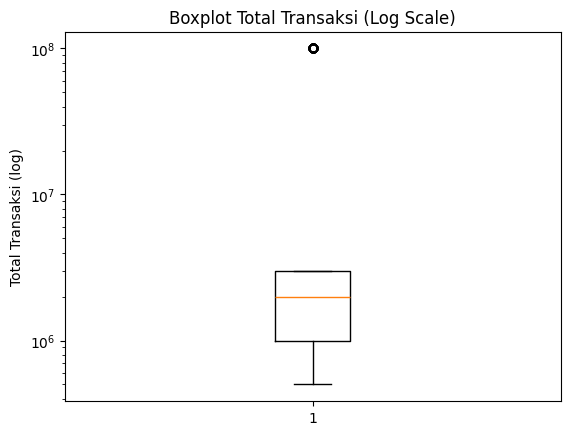

In [29]:
plt.boxplot(data["total_transaksi"].dropna())
plt.yscale("log")
plt.title("Boxplot Total Transaksi (Log Scale)")
plt.ylabel("Total Transaksi (log)")
plt.show()

In [30]:
data["total_transaksi"].describe()

count    6.000000e+02
mean     1.853917e+07
std      3.712254e+07
min      5.000000e+05
25%      1.000000e+06
50%      2.000000e+06
75%      3.000000e+06
max      1.000000e+08
Name: total_transaksi, dtype: float64

Penjelasan:

- Q1 â†’ kuartil bawah (25%)
- Q3 â†’ kuartil atas (75%)
- IQR â†’ rentang data tengah
- Q3 + 1.5 Ã— IQR â†’ batas atas nilai wajar
- Nilai di atas batas tersebut dibatasi (bukan dihapus)

In [31]:
Q1 = data["total_transaksi"].quantile(0.25)
Q3 = data["total_transaksi"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
data.loc[data["total_transaksi"] > upper_bound, "total_transaksi"] = upper_bound

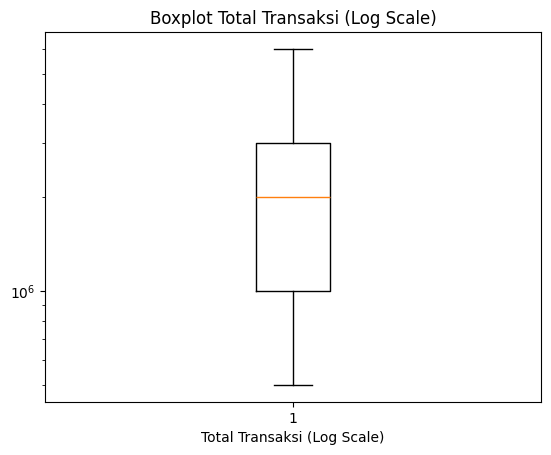

In [32]:
plt.boxplot(data["total_transaksi"].dropna())
plt.yscale("log")
plt.title("Boxplot Total Transaksi (Log Scale)")
plt.xlabel("Total Transaksi (Log Scale)")
plt.show()

Identifikasi atribut kategorikal

Penjelasan kode:
- select_dtypes(include="object") â†’ memilih kolom bertipe teks
- columns â†’ menampilkan nama kolom

In [33]:
data.select_dtypes(include="object").columns

Index(['nama', 'jenis_kelamin', 'kota', 'jenis_produk', 'nama_produk',
       'tanggal_transaksi', 'kategori_umur'],
      dtype='object')

Import library

Penjelasan:
- Mengimpor kelas LabelEncoder dari scikit-learn
- Digunakan untuk mengubah kategori → angka

In [34]:
from sklearn.preprocessing import LabelEncoder

Encoding

Penjelasan baris per baris:
- LabelEncoder() → membuat objek encoder
- fit_transform():
    - fit → mempelajari kategori unik
    - transform â†’ mengonversi kategori menjadi angka
- Hasil disimpan di kolom baru jenis_kelamin_enc

In [35]:
# Encoding jenis_kelamin
le_jenis_kelamin = LabelEncoder()
data["jenis_kelamin_enc"] = le_jenis_kelamin.fit_transform(data["jenis_kelamin"])

# Encoding jenis_produk
le_jenis_produk = LabelEncoder()
data["jenis_produk_enc"] = le_jenis_produk.fit_transform(data["jenis_produk"])

# Encoding kota
le_kota = LabelEncoder()
data["kota_enc"] = le_kota.fit_transform(data["kota"])

# Encoding nama_produk
le_nama_produk = LabelEncoder()
data["nama_produk_enc"] = le_nama_produk.fit_transform(data["nama_produk"])

Identifikasi Atribut Numerik yang Akan Dinormalisasi

Normalisasi digunakan untuk menyeragamkan skala data numerik, karena pada dataset Anda terdapat perbedaan skala
yang signifikan, misalnya:
- umur → puluhan
- total_transaksi → jutaan
- hasil encoding â†’ bilangan kecil (0, 1, 2, â€¦)

Tanpa normalisasi:
- Algoritma berbasis jarak (K-Means, KNN) akan lebih dipengaruhi oleh fitur berskala besar
- Fitur berskala kecil menjadi tidak berpengaruh

In [36]:
data.select_dtypes(include=["int64", "float64"]).columns

Index(['id_pelanggan', 'umur', 'total_transaksi'], dtype='object')

Menentukan kolom yang akan dinormalisasikan

In [37]:
kolom_numerik = [
    "umur",
    "total_transaksi",
    "jenis_kelamin_enc",
    "jenis_produk_enc",
    "kota_enc",
    "nama_produk_enc",
]

In [38]:
from sklearn.preprocessing import MinMaxScaler

In [39]:
# encoding
encoder = LabelEncoder()

data["jenis_produk_enc"] = encoder.fit_transform(data["jenis_produk"])
data["kota_enc"] = encoder.fit_transform(data["kota"])
data["nama_produk_enc"] = encoder.fit_transform(data["nama_produk"])

In [40]:
# normalize

kolom_numerik = [
    "umur",
    "total_transaksi",
    "jenis_produk_enc",
    "kota_enc",
    "nama_produk_enc",
]

scaler = MinMaxScaler()
data_normalized = data.copy()
data_normalized[kolom_numerik] = scaler.fit_transform(data[kolom_numerik])

In [41]:
data_normalized[kolom_numerik].describe()

,umur,total_transaksi,jenis_produk_enc,kota_enc,nama_produk_enc
count,475.000000,600.000000,600.000000,600.000000,600.000000
mean,0.260846,0.345909,0.515833,0.450000,0.480758
std,0.318688,0.326959,0.408792,0.328851,0.326261
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.068627,0.090909,0.000000,0.166667,0.181818
50%,0.166667,0.272727,0.500000,0.500000,0.454545
75%,0.264706,0.454545,1.000000,0.666667,0.818182
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [42]:
data[["umur", "total_transaksi"]].head()

,umur,total_transaksi
0,18.0,1000000.0
1,120.0,500000.0
2,NaN,1000000.0
3,45.0,1000000.0
4,45.0,3000000.0


In [43]:
data_normalized[["umur", "total_transaksi"]].head()

,umur,total_transaksi
0,0.000000,0.090909
1,1.000000,0.000000
2,NaN,0.090909
3,0.264706,0.090909
4,0.264706,0.454545


In [44]:
data_normalized.head(20)

,id_pelanggan,nama,umur,jenis_kelamin,kota,jenis_produk,nama_produk,total_transaksi,tanggal_transaksi,kategori_umur,jenis_kelamin_enc,jenis_produk_enc,kota_enc,nama_produk_enc
0,1100,Dewi,0.000000,P,Depok,Kosmetik,Lipstik,0.090909,2024-01-24,Remaja,1,1.0,0.500000,0.454545
1,1002,Citra,1.000000,P,Jakarta,Kosmetik,Lipstik,0.000000,07/01/2024,Lansia,1,1.0,0.666667,0.454545
2,1003,Andi,NaN,L,Bandung,Kosmetik,Skincare Set,0.090909,15-01-2024,Tidak Diketahui,0,1.0,0.000000,0.818182
3,1004,Fajar,0.264706,P,Bogor,Elektronik,Smartphone,0.090909,31-01-2024,Dewasa,1,0.0,0.333333,0.909091
4,1005,Citra,0.264706,L,Bekasi,Elektronik,Power Bank,0.454545,2024-01-09,Dewasa,0,0.0,0.166667,0.636364
5,1006,Rudi,NaN,L,Jakarta,Kosmetik,Lipstik,0.454545,10-01-2024,Tidak Diketahui,0,1.0,0.666667,0.454545
6,1007,Gita,0.039216,L,Depok,Kosmetik,Skincare Set,0.000000,28/01/2024,Remaja,0,1.0,0.500000,0.818182
7,1008,Maman,0.166667,P,Bekasi,Elektronik,Smartphone,0.181818,12/01/2024,Dewasa,1,0.0,0.166667,0.909091
8,1009,Ika,0.039216,L,Bandung,Kosmetik,Bedak,0.090909,2024/01/06,Remaja,0,1.0,0.000000,0.000000
9,1010,Ika,NaN,L,Bekasi,Fashion,Kaos,0.090909,2024-01-27,Tidak Diketahui,0,0.5,0.166667,0.272727


In [45]:
data.head(20)

,id_pelanggan,nama,umur,jenis_kelamin,kota,jenis_produk,nama_produk,total_transaksi,tanggal_transaksi,kategori_umur,jenis_kelamin_enc,jenis_produk_enc,kota_enc,nama_produk_enc
0,1100,Dewi,18.0,P,Depok,Kosmetik,Lipstik,1000000.0,2024-01-24,Remaja,1,2,3,5
1,1002,Citra,120.0,P,Jakarta,Kosmetik,Lipstik,500000.0,07/01/2024,Lansia,1,2,4,5
2,1003,Andi,NaN,L,Bandung,Kosmetik,Skincare Set,1000000.0,15-01-2024,Tidak Diketahui,0,2,0,9
3,1004,Fajar,45.0,P,Bogor,Elektronik,Smartphone,1000000.0,31-01-2024,Dewasa,1,0,2,10
4,1005,Citra,45.0,L,Bekasi,Elektronik,Power Bank,3000000.0,2024-01-09,Dewasa,0,0,1,7
5,1006,Rudi,NaN,L,Jakarta,Kosmetik,Lipstik,3000000.0,10-01-2024,Tidak Diketahui,0,2,4,5
6,1007,Gita,22.0,L,Depok,Kosmetik,Skincare Set,500000.0,28/01/2024,Remaja,0,2,3,9
7,1008,Maman,35.0,P,Bekasi,Elektronik,Smartphone,1500000.0,12/01/2024,Dewasa,1,0,1,10
8,1009,Ika,22.0,L,Bandung,Kosmetik,Bedak,1000000.0,2024/01/06,Remaja,0,2,0,0
9,1010,Ika,NaN,L,Bekasi,Fashion,Kaos,1000000.0,2024-01-27,Tidak Diketahui,0,1,1,3
